In [1]:
pip install Kagglehub

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv("C:\\Users\\DELL\\Desktop\\Jouhara\\flights.csv")

C:\Users\DELL\AppData\Local\Temp\ipykernel_1068\2286840613.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("C:\\Users\\DELL\\Desktop\\Jouhara\\flights.csv")


In [4]:
df.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
columns_needed = [
    'AIRLINE',
    'DEPARTURE_DELAY',
    'ARRIVAL_DELAY',
    'DAY_OF_WEEK',
    'SCHEDULED_DEPARTURE',
    'DISTANCE'
]

df_small = df[columns_needed]


In [6]:
df_small

,AIRLINE,DEPARTURE_DELAY,ARRIVAL_DELAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DISTANCE
0,AS,-11.0,-22.0,4,5,1448
1,AA,-8.0,-9.0,4,10,2330
2,US,-2.0,5.0,4,20,2296
3,AA,-5.0,-9.0,4,20,2342
4,AS,-1.0,-21.0,4,25,1448
...,...,...,...,...,...,...
5819074,B6,-4.0,-26.0,4,2359,2611
5819075,B6,-4.0,-16.0,4,2359,1617
5819076,B6,-9.0,-8.0,4,2359,1598
5819077,B6,-6.0,-10.0,4,2359,1189


In [7]:
df_small.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 6 columns):
 #   Column               Dtype  
---  ------               -----  
 0   AIRLINE              object 
 1   DEPARTURE_DELAY      float64
 2   ARRIVAL_DELAY        float64
 3   DAY_OF_WEEK          int64  
 4   SCHEDULED_DEPARTURE  int64  
 5   DISTANCE             int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 266.4+ MB


In [8]:
df_small.describe()

,DEPARTURE_DELAY,ARRIVAL_DELAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DISTANCE
count,5.732926e+06,5.714008e+06,5.819079e+06,5.819079e+06,5.819079e+06
mean,9.370158e+00,4.407057e+00,3.926941e+00,1.329602e+03,8.223565e+02
std,3.708094e+01,3.927130e+01,1.988845e+00,4.837518e+02,6.077843e+02
min,-8.200000e+01,-8.700000e+01,1.000000e+00,1.000000e+00,2.100000e+01
25%,-5.000000e+00,-1.300000e+01,2.000000e+00,9.170000e+02,3.730000e+02
50%,-2.000000e+00,-5.000000e+00,4.000000e+00,1.325000e+03,6.470000e+02
75%,7.000000e+00,8.000000e+00,6.000000e+00,1.730000e+03,1.062000e+03
max,1.988000e+03,1.971000e+03,7.000000e+00,2.359000e+03,4.983000e+03


In [9]:
df_small.isnull().sum()

AIRLINE                     0
DEPARTURE_DELAY         86153
ARRIVAL_DELAY          105071
DAY_OF_WEEK                 0
SCHEDULED_DEPARTURE         0
DISTANCE                    0
dtype: int64

In [10]:
df_small.isnull().sum().sort_values()

AIRLINE                     0
DAY_OF_WEEK                 0
SCHEDULED_DEPARTURE         0
DISTANCE                    0
DEPARTURE_DELAY         86153
ARRIVAL_DELAY          105071
dtype: int64

In [11]:

df_small['ARRIVAL_DELAY'] = df_small['ARRIVAL_DELAY'].fillna(df_small['ARRIVAL_DELAY'].mean())
df_small['DEPARTURE_DELAY'] = df_small['DEPARTURE_DELAY'].fillna(df_small['DEPARTURE_DELAY'].mean())


C:\Users\DELL\AppData\Local\Temp\ipykernel_1068\4031559904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['ARRIVAL_DELAY'] = df_small['ARRIVAL_DELAY'].fillna(df_small['ARRIVAL_DELAY'].mean())
C:\Users\DELL\AppData\Local\Temp\ipykernel_1068\4031559904.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small['DEPARTURE_DELAY'] = df_small['DEPARTURE_DELAY'].fillna(df_small['DEPARTURE_DELAY'].mean())


In [12]:
df_small.head()

df_small.tail()

df_small['AIRLINE'].unique()


array(['AS', 'AA', 'US', 'DL', 'NK', 'UA', 'HA', 'B6', 'OO', 'EV', 'MQ',
       'F9', 'WN', 'VX'], dtype=object)

In [13]:
print(df_small['AIRLINE'].value_counts())

print(df_small['DAY_OF_WEEK'].value_counts())



WN    1261855
DL     875881
AA     725984
OO     588353
EV     571977
UA     515723
MQ     294632
B6     267048
US     198715
AS     172521
NK     117379
F9      90836
HA      76272
VX      61903
Name: AIRLINE, dtype: int64
4    872521
1    865543
5    862209
3    855897
2    844600
7    817764
6    700545
Name: DAY_OF_WEEK, dtype: int64


In [14]:
print("ARRIVAL_DELAY mean",df_small['ARRIVAL_DELAY'].mean())
print("DEPARTURE_DELAY mean",df_small['DEPARTURE_DELAY'].mean())
print("ARRIVAL_DELAY mean",df_small.groupby('AIRLINE')['ARRIVAL_DELAY'].mean())

ARRIVAL_DELAY mean 4.407057357998102
DEPARTURE_DELAY mean 9.37015827520495
ARRIVAL_DELAY mean AIRLINE
AA     3.468550
AS    -0.942799
B6     6.635293
DL     0.213765
EV     6.519779
F9    12.438204
HA     2.030313
MQ     6.347611
NK    14.284359
OO     5.817438
UA     5.415779
US     3.722052
VX     4.734207
WN     4.375458
Name: ARRIVAL_DELAY, dtype: float64


In [15]:
df_small.columns

Index(['AIRLINE', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DAY_OF_WEEK',
       'SCHEDULED_DEPARTURE', 'DISTANCE'],
      dtype='object')

In [16]:
df_small.groupby("AIRLINE")["ARRIVAL_DELAY"].mean().sort_values(ascending=False)

AIRLINE
NK    14.284359
F9    12.438204
B6     6.635293
EV     6.519779
MQ     6.347611
OO     5.817438
UA     5.415779
VX     4.734207
WN     4.375458
US     3.722052
AA     3.468550
HA     2.030313
DL     0.213765
AS    -0.942799
Name: ARRIVAL_DELAY, dtype: float64

In [17]:
df_small.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"].mean()

DAY_OF_WEEK
1    5.958299
2    4.249320
3    3.853771
4    5.647178
5    4.759598
6    1.892268
7    3.966639
Name: ARRIVAL_DELAY, dtype: float64

In [18]:
import numpy as np

In [19]:
df_small["DELAY_STATUS"] = np.where(df_small["ARRIVAL_DELAY"] > 0, "Delayed", "On Time")


C:\Users\DELL\AppData\Local\Temp\ipykernel_1068\4188790932.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_small["DELAY_STATUS"] = np.where(df_small["ARRIVAL_DELAY"] > 0, "Delayed", "On Time")


In [20]:
df_small["DELAY_STATUS"].value_counts()


On Time    3627112
Delayed    2191967
Name: DELAY_STATUS, dtype: int64

In [21]:
df_small.corr()

,DEPARTURE_DELAY,ARRIVAL_DELAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DISTANCE
DEPARTURE_DELAY,1.000000,0.938248,-0.011409,0.109268,0.023967
ARRIVAL_DELAY,0.938248,1.000000,-0.016848,0.099264,-0.025249
DAY_OF_WEEK,-0.011409,-0.016848,1.000000,0.008007,0.016516
SCHEDULED_DEPARTURE,0.109268,0.099264,0.008007,1.000000,-0.009572
DISTANCE,0.023967,-0.025249,0.016516,-0.009572,1.000000


In [22]:
df.corr()

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
YEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MONTH,NaN,1.000000,0.008874,-0.007847,-0.020746,0.000207,-0.004085,-0.021994,-0.013117,-0.004946,...,-0.010121,-0.009133,-0.036793,-0.000991,-0.055043,-0.002214,0.007925,0.011262,0.004839,-0.008682
DAY,NaN,0.008874,1.000000,0.001111,0.001855,-0.001647,-0.002644,-0.000176,-0.002661,-0.003318,...,-0.003688,-0.004310,-0.003097,0.001981,-0.003537,-0.007375,-0.000510,0.006728,0.008869,0.008882
DAY_OF_WEEK,NaN,-0.007847,0.001111,1.000000,0.014461,0.008007,0.005607,-0.011510,-0.020639,0.004060,...,0.007092,0.005641,-0.017027,-0.001442,-0.022230,-0.023674,0.001576,0.011264,-0.018026,-0.006794
FLIGHT_NUMBER,NaN,-0.020746,0.001855,0.014461,1.000000,-0.005485,-0.001444,-0.008665,0.050369,0.005289,...,-0.013947,-0.002821,0.018419,0.003802,0.037895,-0.009235,-0.007994,0.007168,0.022274,-0.002836
SCHEDULED_DEPARTURE,NaN,0.000207,-0.001647,0.008007,-0.005485,1.000000,0.963791,0.110149,0.006581,0.938008,...,0.706237,0.629342,0.100220,-0.000752,0.011752,-0.075174,-0.005068,-0.089095,0.145054,-0.013470
DEPARTURE_TIME,NaN,-0.004085,-0.002644,0.005607,-0.001444,0.963791,1.000000,0.171723,0.014002,0.971971,...,0.710223,0.648265,0.159787,0.001425,0.008055,-0.043878,-0.004682,-0.024131,0.182374,-0.004221
DEPARTURE_DELAY,NaN,-0.021994,-0.000176,-0.011510,-0.008665,0.110149,0.171723,1.000000,0.058515,0.162582,...,0.097566,0.049236,0.944672,0.022963,0.033099,0.095917,0.011877,0.621296,0.554802,0.243532
TAXI_OUT,NaN,-0.013117,-0.002661,-0.020639,0.050369,0.006581,0.014002,0.058515,1.000000,0.039104,...,0.024384,0.029745,0.227319,0.012251,0.005062,0.361659,-0.005988,-0.070290,-0.127824,0.063308
WHEELS_OFF,NaN,-0.004946,-0.003318,0.004060,0.005289,0.938008,0.971971,0.162582,0.039104,1.000000,...,0.721877,0.667991,0.155773,0.001667,0.004805,-0.026377,-0.006180,-0.032810,0.156089,-0.008338


In [23]:
df[['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','WEATHER_DELAY']].sum() 

AIR_SYSTEM_DELAY    14335762.0
SECURITY_DELAY         80985.0
AIRLINE_DELAY       20172956.0
WEATHER_DELAY        3100233.0
dtype: float64

In [24]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [25]:
import matplotlib.pyplot as plt

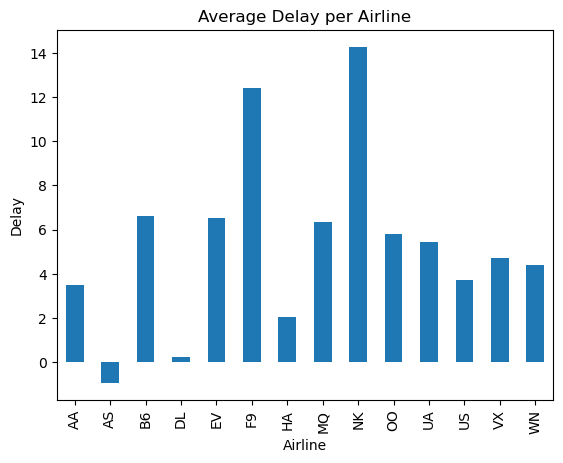

In [26]:

df_small.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().plot(kind='bar')
plt.title("Average Delay per Airline")
plt.xlabel("Airline")
plt.ylabel("Delay")
plt.show()


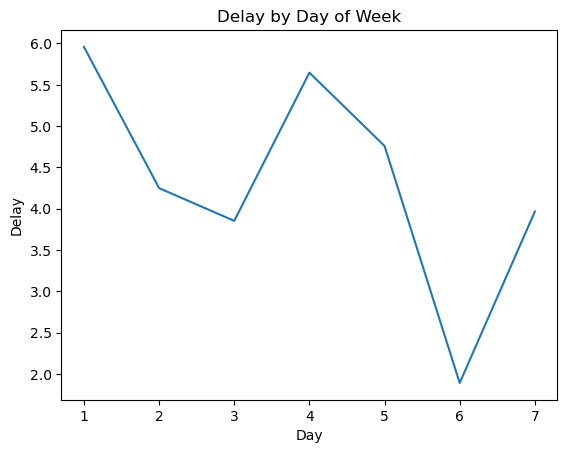

In [27]:
df_small.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].mean().plot(kind='line')
plt.title("Delay by Day of Week")
plt.xlabel("Day")
plt.ylabel("Delay")
plt.show()


In [28]:
import matplotlib.pyplot as plt

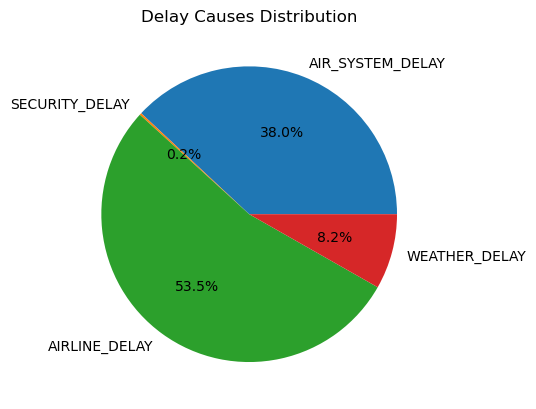

In [29]:
delay_causes = df[['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','WEATHER_DELAY']].sum()

delay_causes.plot(kind='pie', autopct='%1.1f%%')
plt.title("Delay Causes Distribution")
plt.ylabel("")
plt.show()

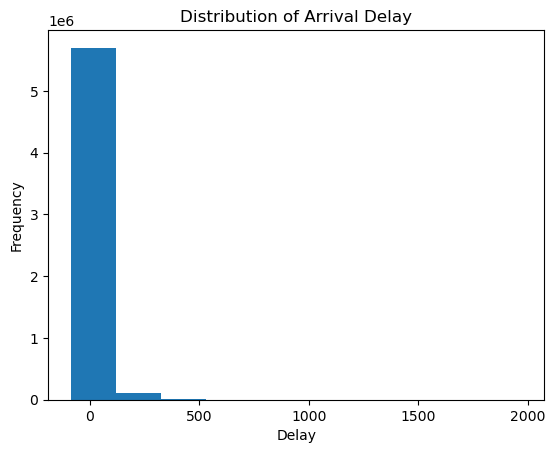

In [30]:
df_small['ARRIVAL_DELAY'].plot(kind='hist')
plt.title("Distribution of Arrival Delay")
plt.xlabel("Delay")
plt.show()


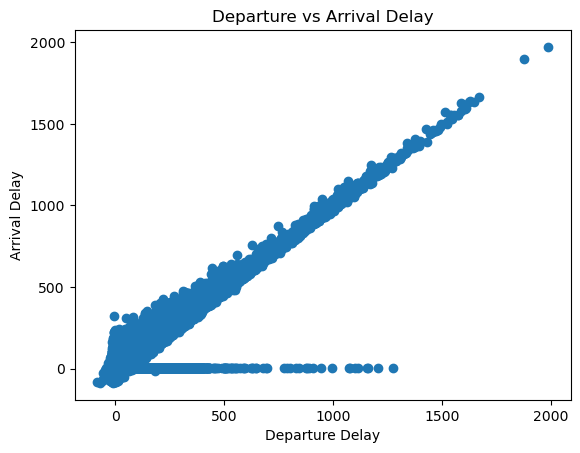

In [31]:
plt.scatter(df_small['DEPARTURE_DELAY'], df_small['ARRIVAL_DELAY'])
plt.xlabel("Departure Delay")
plt.ylabel("Arrival Delay")
plt.title("Departure vs Arrival Delay")
plt.show()


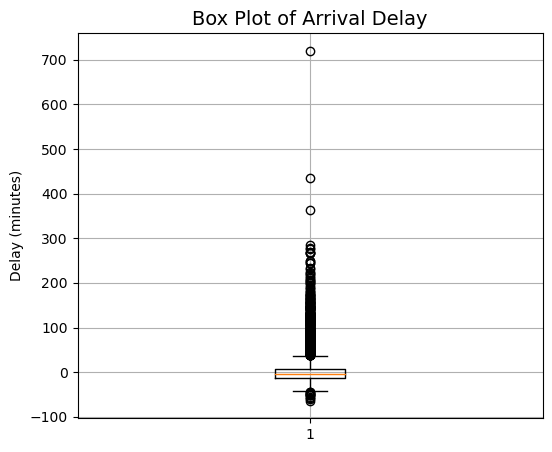

In [32]:

df_box = df_small[['ARRIVAL_DELAY']].dropna().sample(5000)

plt.figure(figsize=(6,5))

plt.boxplot(df_box['ARRIVAL_DELAY'])

plt.title("Box Plot of Arrival Delay", fontsize=14)
plt.ylabel("Delay (minutes)")

plt.grid(True)
plt.show()





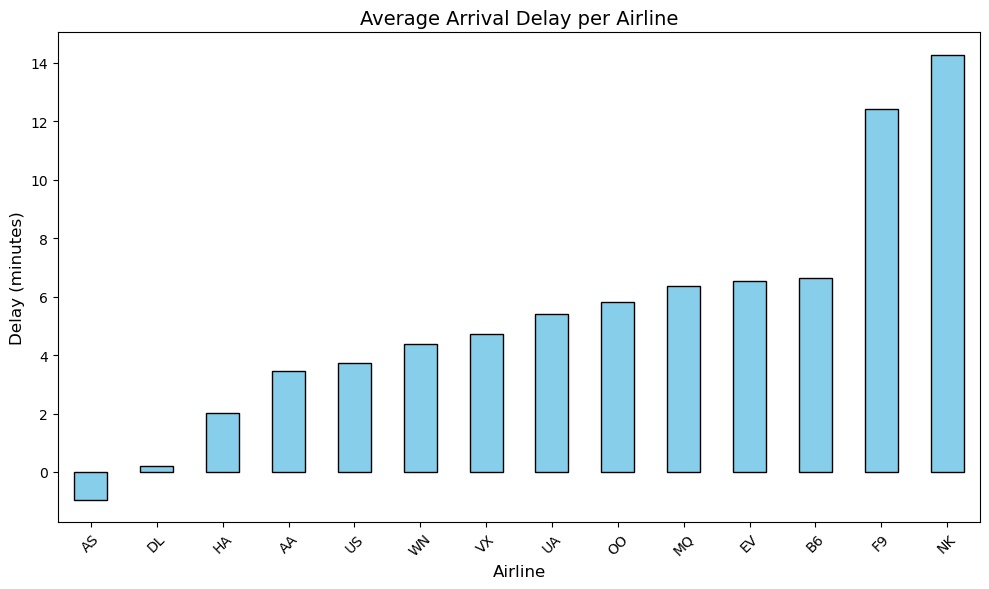

In [33]:
airline_delay = df_small.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values()

plt.figure(figsize=(10,6))

airline_delay.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title("Average Arrival Delay per Airline", fontsize=14)
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Delay (minutes)", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


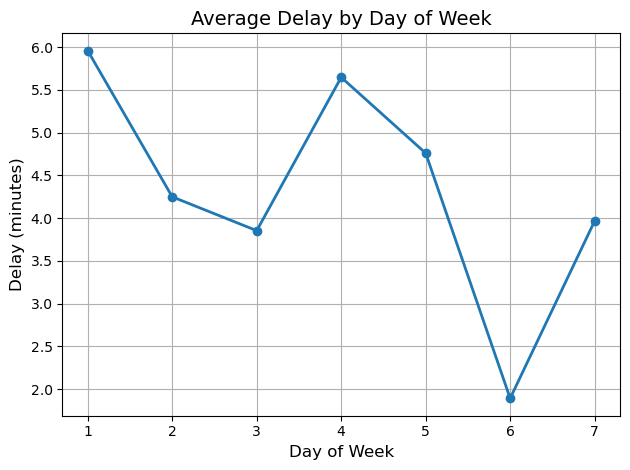

In [34]:
day_delay = df_small.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].mean()

day_delay.plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title("Average Delay by Day of Week", fontsize=14)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Delay (minutes)", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()

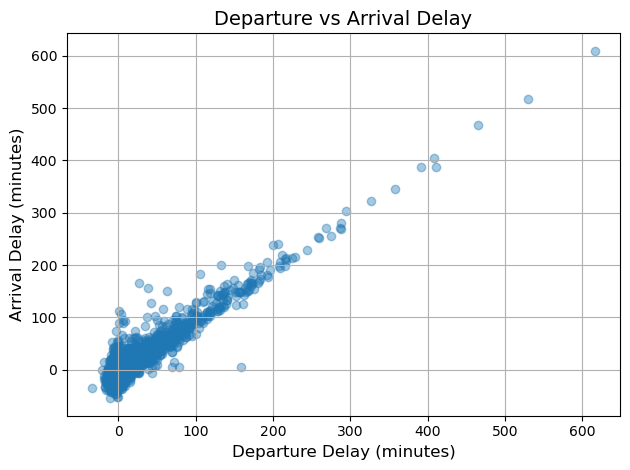

In [35]:
df_plot = df_small[['DEPARTURE_DELAY','ARRIVAL_DELAY']].dropna().sample(5000)

plt.scatter(
    df_plot['DEPARTURE_DELAY'],
    df_plot['ARRIVAL_DELAY'],
    alpha=0.4
)

plt.title("Departure vs Arrival Delay", fontsize=14)
plt.xlabel("Departure Delay (minutes)", fontsize=12)
plt.ylabel("Arrival Delay (minutes)", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()


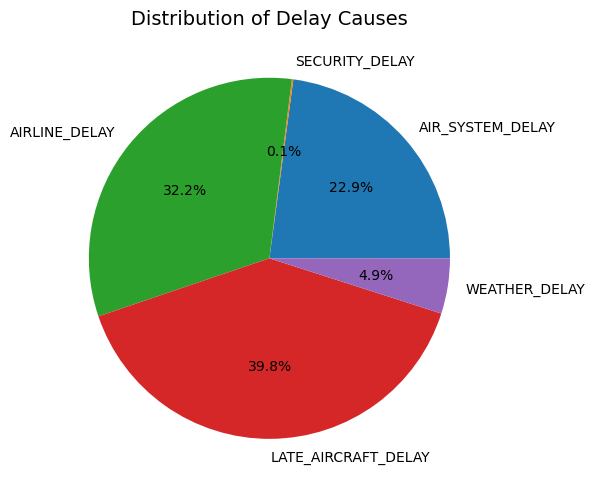

In [36]:
delay_causes = df[['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY']].sum()

plt.figure(figsize=(6,6))

delay_causes.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Distribution of Delay Causes", fontsize=14)
plt.ylabel("")
plt.tight_layout()
plt.show()


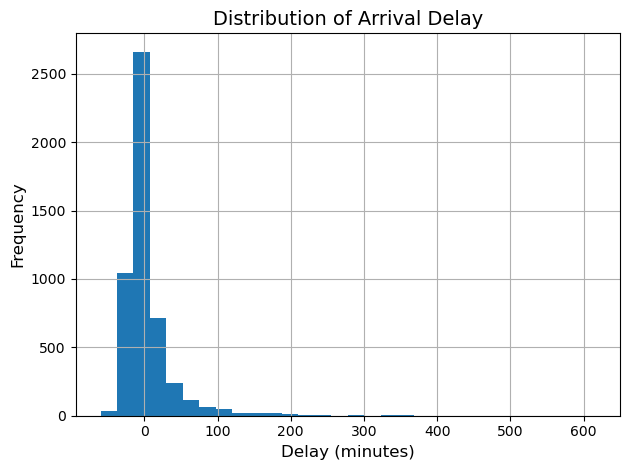

In [37]:
df_hist = df_small['ARRIVAL_DELAY'].dropna().sample(5000)


plt.hist(df_hist, bins=30)

plt.title("Distribution of Arrival Delay", fontsize=14)
plt.xlabel("Delay (minutes)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()

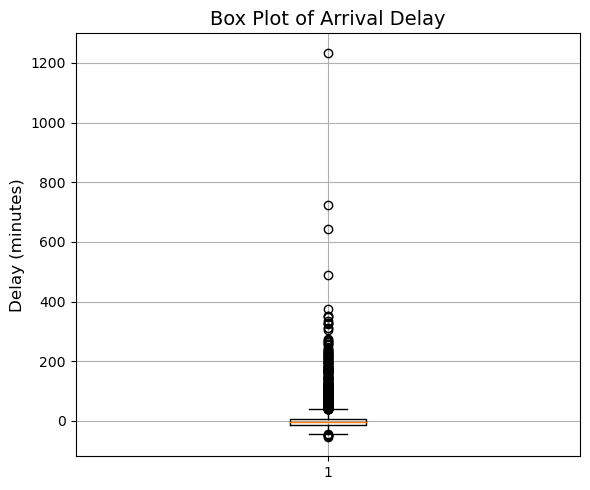

In [38]:
df_box = df_small['ARRIVAL_DELAY'].dropna().sample(5000)

plt.figure(figsize=(6,5))

plt.boxplot(df_box)

plt.title("Box Plot of Arrival Delay", fontsize=14)
plt.ylabel("Delay (minutes)", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
df_small.loc[df_small['ARRIVAL_DELAY'] > 0]


,AIRLINE,DEPARTURE_DELAY,ARRIVAL_DELAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DISTANCE,DELAY_STATUS
2,US,-2.0,5.0,4,20,2296,Delayed
5,DL,-5.0,8.0,4,25,1589,Delayed
14,DL,-1.0,8.0,4,40,1399,Delayed
20,NK,25.0,6.0,4,55,1139,Delayed
21,AA,-8.0,1.0,4,100,2724,Delayed
...,...,...,...,...,...,...,...
5819057,NK,13.0,28.0,4,2358,982,Delayed
5819069,B6,159.0,159.0,4,2359,2248,Delayed
5819071,B6,16.0,17.0,4,2359,1931,Delayed
5819073,B6,16.0,3.0,4,2359,1826,Delayed


In [40]:
df_small.loc[df_small['ARRIVAL_DELAY'] > 60]

,AIRLINE,DEPARTURE_DELAY,ARRIVAL_DELAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DISTANCE,DELAY_STATUS
52,B6,95.0,85.0,4,400,1189,Delayed
55,B6,72.0,89.0,4,438,1666,Delayed
70,AA,108.0,102.0,4,515,1121,Delayed
86,AA,53.0,66.0,4,530,641,Delayed
102,UA,56.0,78.0,4,538,909,Delayed
...,...,...,...,...,...,...,...
5818876,F9,147.0,119.0,4,2225,1199,Delayed
5818886,UA,80.0,68.0,4,2230,416,Delayed
5818975,NK,104.0,100.0,4,2310,1055,Delayed
5819008,AA,190.0,234.0,4,2330,2845,Delayed


In [41]:
df_small.loc[df_small['ARRIVAL_DELAY'] < 0]


,AIRLINE,DEPARTURE_DELAY,ARRIVAL_DELAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DISTANCE,DELAY_STATUS
0,AS,-11.0,-22.0,4,5,1448,On Time
1,AA,-8.0,-9.0,4,10,2330,On Time
3,AA,-5.0,-9.0,4,20,2342,On Time
4,AS,-1.0,-21.0,4,25,1448,On Time
6,NK,-6.0,-17.0,4,25,1299,On Time
...,...,...,...,...,...,...,...
5819072,B6,7.0,-11.0,4,2359,1626,On Time
5819074,B6,-4.0,-26.0,4,2359,2611,On Time
5819075,B6,-4.0,-16.0,4,2359,1617,On Time
5819076,B6,-9.0,-8.0,4,2359,1598,On Time


In [42]:
df_small.loc[df_small['ARRIVAL_DELAY'].between(10, 60)]

,AIRLINE,DEPARTURE_DELAY,ARRIVAL_DELAY,DAY_OF_WEEK,SCHEDULED_DEPARTURE,DISTANCE,DELAY_STATUS
27,NK,12.0,25.0,4,115,1487,Delayed
30,NK,72.0,43.0,4,125,1440,Delayed
33,DL,-6.0,10.0,4,140,1590,Delayed
35,HA,0.0,15.0,4,145,2762,Delayed
39,B6,-2.0,11.0,4,155,1598,Delayed
...,...,...,...,...,...,...,...
5819023,B6,21.0,20.0,4,2342,1129,Delayed
5819033,DL,26.0,11.0,4,2350,1947,Delayed
5819051,AS,16.0,28.0,4,2355,1399,Delayed
5819057,NK,13.0,28.0,4,2358,982,Delayed


In [43]:
print(df_small.loc[df_small['ARRIVAL_DELAY'].between(15,60), ['AIRLINE','ARRIVAL_DELAY']])


        AIRLINE  ARRIVAL_DELAY
27           NK           25.0
30           NK           43.0
35           HA           15.0
50           B6           20.0
73           US           60.0
...         ...            ...
5819011      B6           47.0
5819023      B6           20.0
5819051      AS           28.0
5819057      NK           28.0
5819071      B6           17.0

[744347 rows x 2 columns]


In [44]:
print(df_small.loc[df_small['ARRIVAL_DELAY'].between(120,300), ['AIRLINE','ARRIVAL_DELAY']])

        AIRLINE  ARRIVAL_DELAY
106          DL          128.0
165          EV          226.0
174          UA          123.0
369          OO          144.0
493          MQ          161.0
...         ...            ...
5818593      EV          120.0
5818809      AA          228.0
5818836      DL          204.0
5819008      AA          234.0
5819069      B6          159.0

[105214 rows x 2 columns]


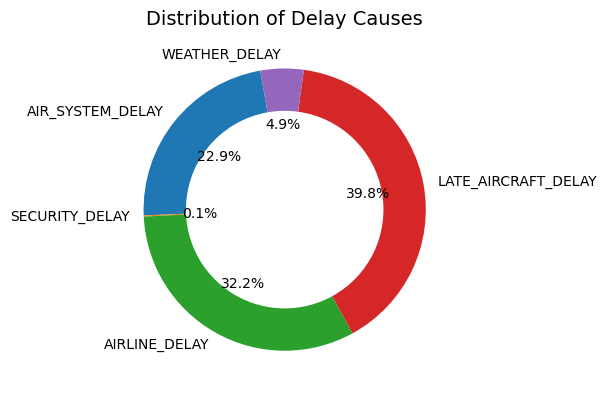

In [45]:
delay_causes = df[['AIR_SYSTEM_DELAY','SECURITY_DELAY','AIRLINE_DELAY','LATE_AIRCRAFT_DELAY','WEATHER_DELAY']].sum()

plt.figure(figsize=(6,6))

delay_causes.plot(
    kind='pie',
    autopct='%1.1f%%',
   startangle=100,
    wedgeprops={'width': 0.3} 
)

plt.title("Distribution of Delay Causes", fontsize=14)
plt.ylabel("")
plt.tight_layout()
plt.show()


 

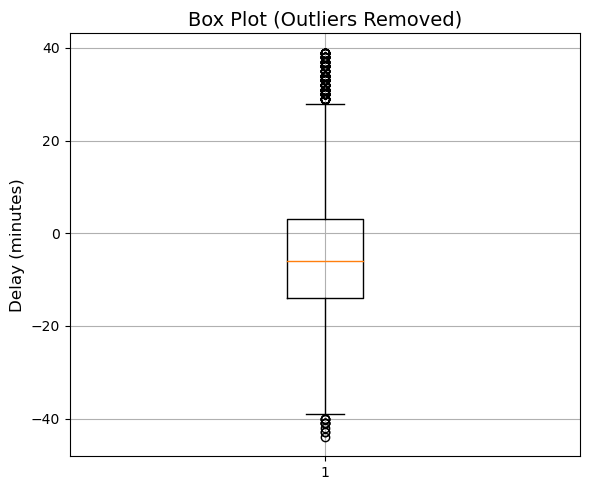

In [46]:
import numpy as np
import matplotlib.pyplot as plt

df_box = df_small['ARRIVAL_DELAY'].dropna().sample(5000)

# IQR steps (simple)
q1 = df_box.quantile(0.25)
q2 = df_box.quantile(0.50)
q3 = df_box.quantile(0.75)

iqr = q3 - q1

low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

# remove outliers
df_clean = df_box[(df_box >= low) & (df_box <= high)]

# plot
plt.figure(figsize=(6,5))
plt.boxplot(df_clean)

plt.title("Box Plot (Outliers Removed)", fontsize=14)
plt.ylabel("Delay (minutes)", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()

Q1: -14.0
Q2 (Median): -5.0
Q3: 6.0
Lower bound: -44.0
Upper bound: 36.0


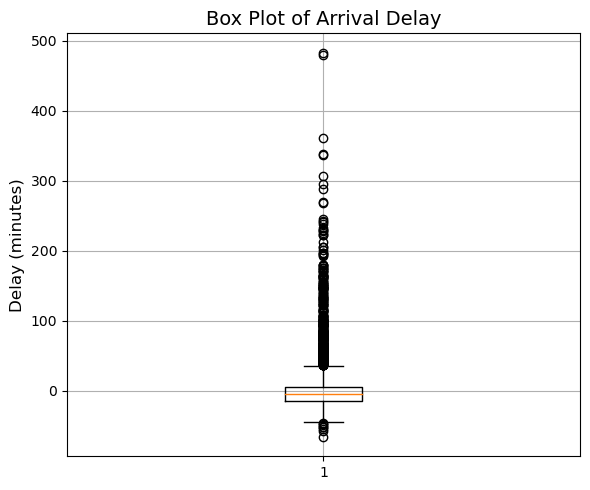

In [47]:
import matplotlib.pyplot as plt

df_box = df_small['ARRIVAL_DELAY'].dropna().sample(5000)
q1 = df_box.quantile(0.25)
q2 = df_box.quantile(0.50)  
q3 = df_box.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print("Q1:", q1)
print("Q2 (Median):", q2)
print("Q3:", q3)
print("Lower bound:", lower)
print("Upper bound:", upper)


plt.figure(figsize=(6,5))
plt.boxplot(df_box)

plt.title("Box Plot of Arrival Delay", fontsize=14)
plt.ylabel("Delay (minutes)", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()

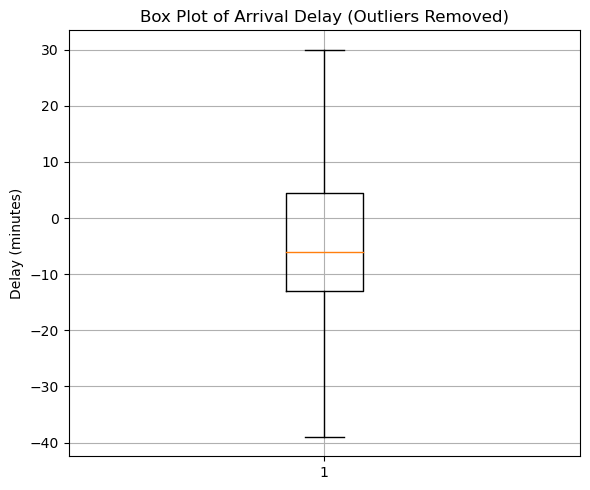

In [48]:
import matplotlib.pyplot as plt

df_box = df_small['ARRIVAL_DELAY'].dropna().sample(5000, random_state=42)

q1 = df_box.quantile(0.25)
q3 = df_box.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df_clean = df_box[(df_box >= lower) & (df_box <= upper)]

plt.figure(figsize=(6,5))
plt.boxplot(df_clean, showfliers=False)

plt.title("Box Plot of Arrival Delay (Outliers Removed)")
plt.ylabel("Delay (minutes)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


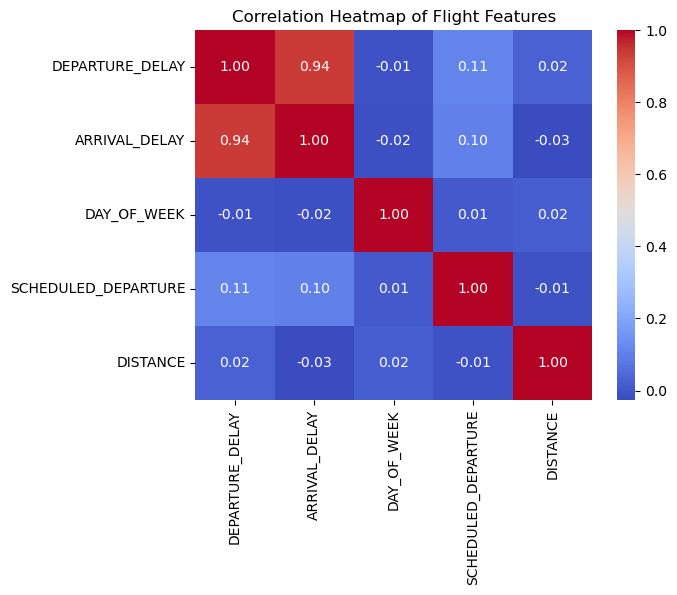

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = df_small.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Flight Features')
plt.show()

In [51]:
import joypy

import matplotlib.pyplot as plt

df_ridge = df_small[(df_small['ARRIVAL_DELAY'] >= -43) & (df_small['ARRIVAL_DELAY'] <= 37)]

fig, axes = joypy.joyplot(df_ridge, column='ARRIVAL_DELAY', by='DAY_OF_WEEK', 

                          title="Delay Distribution by Day", 

                          colormap=plt.cm.viridis, alpha=0.8)


plt.show()

ModuleNotFoundError: No module named 'joypy'

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

df_clean = df_small[(df_small['ARRIVAL_DELAY'] >= -43) & (df_small['ARRIVAL_DELAY'] <= 37)]

plt.figure(figsize=(12, 6))

sns.violinplot(x='DAY_OF_WEEK', y='ARRIVAL_DELAY', data=df_clean, palette='muted', inner='quartile')

plt.title('Flight Delays Distribution by Day (Violin Plot)', fontsize=15)

plt.xlabel('Day of the Week')

plt.ylabel('Delay (Minutes)')

plt.show()

In [ ]:
import plotly.express as px

df_sample = df_small.sample(50, random_state=42).copy()

#
df_sample = df_sample.dropna(subset=[
    'DAY_OF_WEEK', 'AIRLINE', 'DELAY_STATUS', 'ARRIVAL_DELAY'
])

df_sample['DELAY_SIZE'] = df_sample['ARRIVAL_DELAY'].abs()
df_sample = df_sample[df_sample['DELAY_SIZE'] > 0]
day_map = {1:"Mon",2:"Tue",3:"Wed",4:"Thu",5:"Fri",6:"Sat",7:"Sun"}
df_sample['DAY_OF_WEEK'] = df_sample['DAY_OF_WEEK'].map(day_map)
fig = px.sunburst(
    df_sample,
    path=['DAY_OF_WEEK', 'AIRLINE', 'DELAY_STATUS'],
    values='DELAY_SIZE',
    color='ARRIVAL_DELAY',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0
)

fig.update_layout(title="Hierarchical Analysis of Flight Delays")

fig.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 5 airlines
top_airlines = df_small['AIRLINE'].value_counts().nlargest(5).index

# Filter data
df_joy = df_small[df_small['AIRLINE'].isin(top_airlines)].copy()

# Create FacetGrid
g = sns.FacetGrid(
    df_joy,
    row="AIRLINE",
    hue="AIRLINE",
    aspect=4,
    height=1.5,
    palette="viridis"
)

# KDE plots
g.map(sns.kdeplot, "ARRIVAL_DELAY", fill=True, alpha=0.7, lw=1.5)
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Clean styling
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Add airline labels (FIXED INDENTATION)
for i, ax in enumerate(g.axes.flat):
    ax.text(
        -15, 0.02,
        top_airlines[i],
        fontweight='bold',
        fontsize=12,
        color=ax.lines[0].get_color()
    )

# Adjust layout
plt.subplots_adjust(hspace=-0.3)
plt.xlim(-20, 100)

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_small = df_small.copy()
df_small['HOUR'] = (df_small['SCHEDULED_DEPARTURE'] // 100).astype(int)


day_map = {
    1: "Mon", 2: "Tue", 3: "Wed",
    4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"
}
df_small['DAY_OF_WEEK'] = df_small['DAY_OF_WEEK'].map(day_map)

order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
df_small['DAY_OF_WEEK'] = pd.Categorical(
    df_small['DAY_OF_WEEK'],
    categories=order,
    ordered=True
)

pivot_table = df_small.pivot_table(
    index='DAY_OF_WEEK',
    columns='HOUR',
    values='ARRIVAL_DELAY',
    aggfunc='mean'
)

plt.figure(figsize=(15, 8))
sns.heatmap(
    pivot_table,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Average Delay (minutes)'}
)

plt.title('When Do the Worst Delays Occur? (Hour of Day vs Day of Week)', fontsize=15)
plt.xlabel('Departure Hour (0–23)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 5 airlines
top_airlines = df_small['AIRLINE'].value_counts().nlargest(5).index

# Filter data
df_joy = df_small[df_small['AIRLINE'].isin(top_airlines)].copy()

# Create FacetGrid
g = sns.FacetGrid(
    df_joy,
    row="AIRLINE",
    hue="AIRLINE",
    aspect=4,
    height=1.5,
    palette="viridis"
)

# KDE plots
g.map(sns.kdeplot, "ARRIVAL_DELAY", fill=True, alpha=0.7, lw=1.5)
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Clean styling
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# Add airline labels (FIXED INDENTATION)
for i, ax in enumerate(g.axes.flat):
    ax.text(
        -15, 0.02,
        top_airlines[i],
        fontweight='bold',
        fontsize=12,
        color=ax.lines[0].get_color()
    )

# Adjust layout
plt.subplots_adjust(hspace=-0.3)
plt.xlim(-20, 100)

plt.show()

In [ ]:
import plotly.express as px

# اختيار عينة عشوائية بسيطة لضمان سرعة الرسم ووضوح الخطوط
df_sample = df_small.sample(500)

# رسم المخطط المتوازي يربط بين الشركة، اليوم، وحالة التأخير
fig = px.parallel_categories(df_sample,
dimensions=['AIRLINE', 'DAY_OF_WEEK', 'DELAY_STATUS'],
color="ARRIVAL_DELAY",
color_continuous_scale=px.colors.sequential.Inferno)

fig.update_layout(title="Multi-Dimensional Flight Path Analysis")
fig.show()

In [ ]:
import plotly.express as px

df_sample = df_small.sample(7000, random_state=42).copy()

#
df_sample = df_sample.dropna(subset=[
    'DAY_OF_WEEK', 'AIRLINE', 'DELAY_STATUS', 'ARRIVAL_DELAY'
])

df_sample['DELAY_SIZE'] = df_sample['ARRIVAL_DELAY'].abs()
df_sample = df_sample[df_sample['DELAY_SIZE'] > 0]
day_map = {1:"Mon",2:"Tue",3:"Wed",4:"Thu",5:"Fri",6:"Sat",7:"Sun"}
df_sample['DAY_OF_WEEK'] = df_sample['DAY_OF_WEEK'].map(day_map)
fig = px.sunburst(
    df_sample,
    path=['DAY_OF_WEEK', 'AIRLINE', 'DELAY_STATUS'],
    values='DELAY_SIZE',
    color='ARRIVAL_DELAY',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0
)

fig.update_layout(title="Hierarchical Analysis of Flight Delays")

fig.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.violinplot(x='DAY_OF_WEEK', y='ARRIVAL_DELAY', data=df_small, palette='muted', inner='quartile')
plt.title('Flight Delays Distribution by Day (Violin Plot)', fontsize=14)
plt.xlabel('Day of the Week (1=Mon, 7=Sun)')
plt.ylabel('Delay (Minutes)')

plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
day_names = {1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'}
df_small['DAY_NAME'] = df_small['DAY_OF_WEEK'].map(day_names)
sns.set_theme(style="whitegrid")     

plot_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax = sns.violinplot(x='DAY_NAME', y='ARRIVAL_DELAY', data=df_small,
order=plot_order, palette='viridis', inner='quartile', cut=0)

plt.ylim(-40, 80)

plt.title('Flight Delay Distribution: Consistency Across the Week', fontsize=16, pad=20)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Arrival Delay (Minutes)', fontsize=12)

plt.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Copy to avoid SettingWithCopyWarning
df_small = df_small.copy()

day_names = {
    1: 'Mon', 2: 'Tue', 3: 'Wed',
    4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'
}
df_small['DAY_NAME'] = df_small['DAY_OF_WEEK'].map(day_names)


df_small = df_small.dropna(subset=['DAY_NAME', 'ARRIVAL_DELAY'])


df_small = df_small[
    (df_small['ARRIVAL_DELAY'] > -50) &
    (df_small['ARRIVAL_DELAY'] < 150)
]
(style="whitegrid")

plot_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    x='DAY_NAME',
    y='ARRIVAL_DELAY',
    data=df_small,
    order=plot_order,
    palette='viridis',
    inner='quartile',
    cut=0
)

plt.ylim(-40, 80)

plt.title('Flight Delay Distribution: Consistency Across the Week', fontsize=16, pad=20)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Arrival Delay (Minutes)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Set seaborn style correctly
sns.set(style="whitegrid")

# Copy to avoid SettingWithCopyWarning
df_small = df_small.copy()

# Map day numbers to names
day_names = {
    1: 'Mon', 2: 'Tue', 3: 'Wed',
    4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'
}
df_small['DAY_NAME'] = df_small['DAY_OF_WEEK'].map(day_names)

# Drop missing values
df_small = df_small.dropna(subset=['DAY_NAME', 'ARRIVAL_DELAY'])

# Remove extreme outliers
df_small = df_small[
    (df_small['ARRIVAL_DELAY'] > -50) &
    (df_small['ARRIVAL_DELAY'] < 150)
]

# Order of days
plot_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Plot
plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    x='DAY_NAME',
    y='ARRIVAL_DELAY',
    data=df_small,
    order=plot_order,
    palette='viridis',
    inner='quartile',
    cut=0
)

# Limits and styling
plt.ylim(-40, 80)
plt.title('Flight Delay Distribution: Consistency Across the Week', fontsize=16, pad=20)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Arrival Delay (Minutes)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
filtered_df = df_small.loc[df_small['ARRIVAL_DELAY'].between(60, 120), ['AIRLINE', 'ARRIVAL_DELAY']]
print(filtered_df)


In [ ]:
airline_delay = df_small.groupby('AIRLINE')['DEPARTURE_DELAY'].mean().sort_values()

plt.figure(figsize=(10,6))

airline_delay.plot(
    kind='bar',
    color='skyblue',
    edgecolor='black'
)

plt.title("Average DEPARTURE DELAY per Airline", fontsize=14)
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Delay (minutes)", fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

dep_delay = df_small.groupby('AIRLINE')['DEPARTURE_DELAY'].mean()
arr_delay = df_small.groupby('AIRLINE')['ARRIVAL_DELAY'].mean()

airline_delay = pd.DataFrame({
    'Departure Delay': dep_delay,
    'Arrival Delay': arr_delay
}).sort_values(by='Arrival Delay')

airline_delay.plot(
    kind='bar',
    figsize=(12, 6),
    color=['skyblue', 'orange'],
    edgecolor='black'
)

plt.title("Average Departure vs Arrival Delay per Airline", fontsize=14)
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Delay (minutes)", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='red', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

day_names = {
    1: 'Mon', 2: 'Tue', 3: 'Wed',
    4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'
}

df_small['DAY_NAME'] = df_small['DAY_OF_WEEK'].map(day_names)

arr_delay = df_small.groupby('DAY_NAME')['ARRIVAL_DELAY'].mean()
dep_delay = df_small.groupby('DAY_NAME')['DEPARTURE_DELAY'].mean()

day_delay = pd.DataFrame({
    'Arrival Delay': arr_delay,
    'Departure Delay': dep_delay
}).reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

day_delay.plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title("Average Arrival vs Departure Delay by Day", fontsize=14)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Delay (minutes)", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

day_names = {
    1: 'Mon', 2: 'Tue', 3: 'Wed',
    4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'
}

df_small['DAY_NAME'] = df_small['DAY_OF_WEEK'].map(day_names)

arr_delay = df_small.groupby('DAY_NAME')['ARRIVAL_DELAY'].mean()
dep_delay = df_small.groupby('DAY_NAME')['DEPARTURE_DELAY'].mean()

day_delay = pd.DataFrame({
    'Arrival Delay': arr_delay,
    'Departure Delay': dep_delay
}).reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

day_delay.plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title("Average Arrival vs Departure Delay by Day", fontsize=14)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Delay (minutes)", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

day_names = {
    1: 'Mon', 2: 'Tue', 3: 'Wed',
    4: 'Thu', 5: 'Fri', 6: 'Sat', 7: 'Sun'
}

df_small['DAY_NAME'] = df_small['DAY_OF_WEEK'].map(day_names)

arr_delay = df_small.groupby('DAY_NAME')['ARRIVAL_DELAY'].mean()
dep_delay = df_small.groupby('DAY_NAME')['DEPARTURE_DELAY'].mean()

day_delay = pd.DataFrame({
    'Arrival Delay': arr_delay,
    'Departure Delay': dep_delay
}).reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

day_delay.plot(
    kind='line',
    marker='o',
    linewidth=2
)

plt.title("Average Arrival vs Departure Delay by Day", fontsize=14)
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Delay (minutes)", fontsize=12)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_small.groupby(['AIRLINE','DAY_OF_WEEK'])['ARRIVAL_DELAY'].mean()

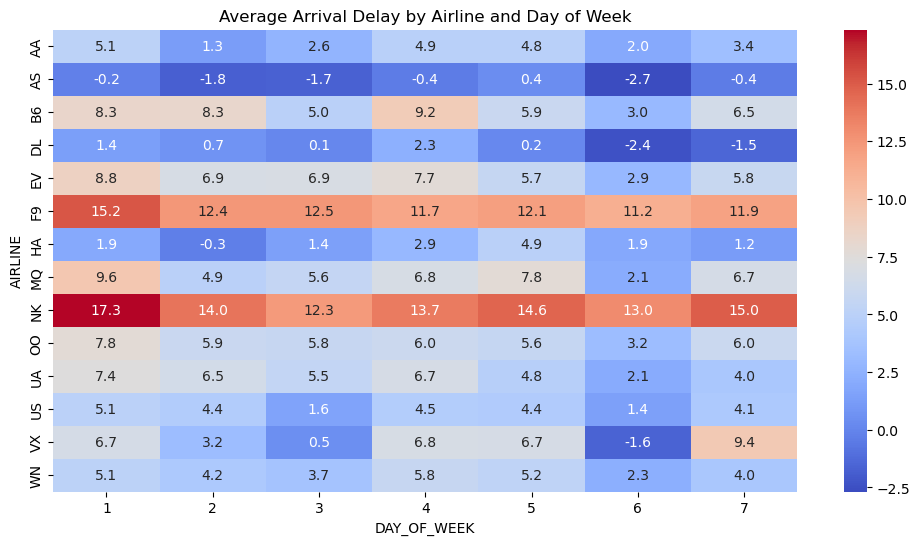

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
result = df_small.groupby(['AIRLINE','DAY_OF_WEEK'])['ARRIVAL_DELAY'].mean().unstack()
sns.heatmap(result, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Average Arrival Delay by Airline and Day of Week")
plt.show()

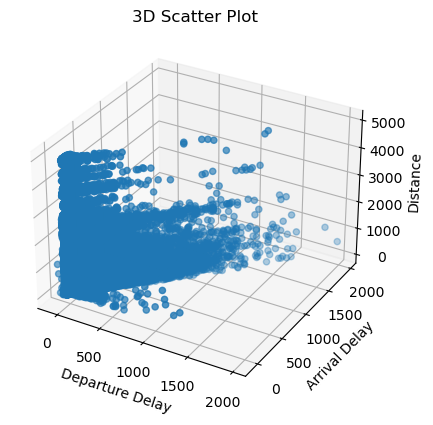

In [56]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_small['DEPARTURE_DELAY'],
    df_small['ARRIVAL_DELAY'],
    df_small['DISTANCE']
)

ax.set_xlabel('Departure Delay')
ax.set_ylabel('Arrival Delay')
ax.set_zlabel('Distance')

plt.title("3D Scatter Plot")
plt.show()

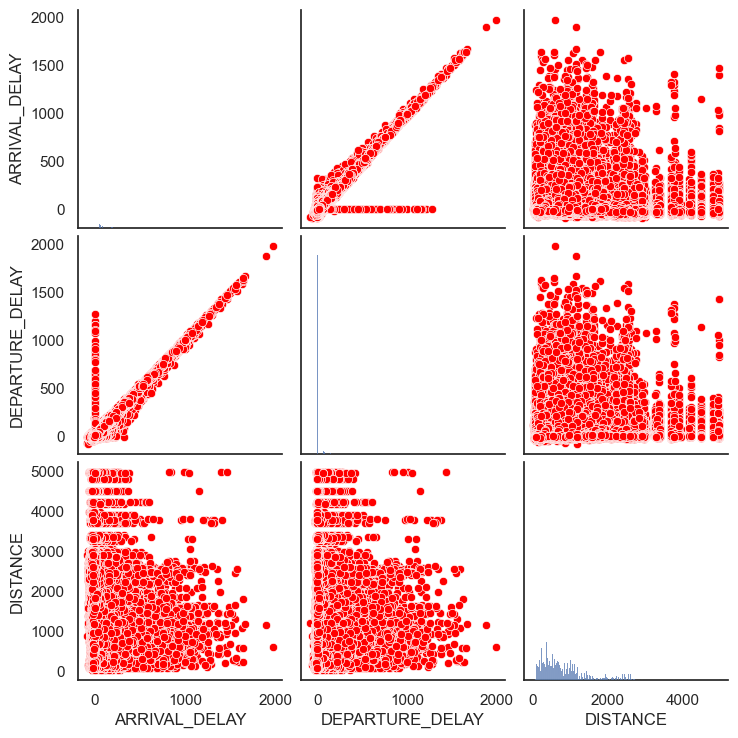

In [63]:
sns.pairplot(
    df_small[['ARRIVAL_DELAY','DEPARTURE_DELAY','DISTANCE']],
    plot_kws={'color': 'red'}
)
plt.show()